# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




Pierwiastki W(x): [-2. -1.]

Obliczone pierwiastki Wilkinsona:
[ 1.          2.          3.          4.00000001  4.99999997  6.00000015
  6.99999933  8.00000223  8.99999482 10.00000797 10.99999226 12.0000043
 12.99999906 13.9999998  15.00000011]



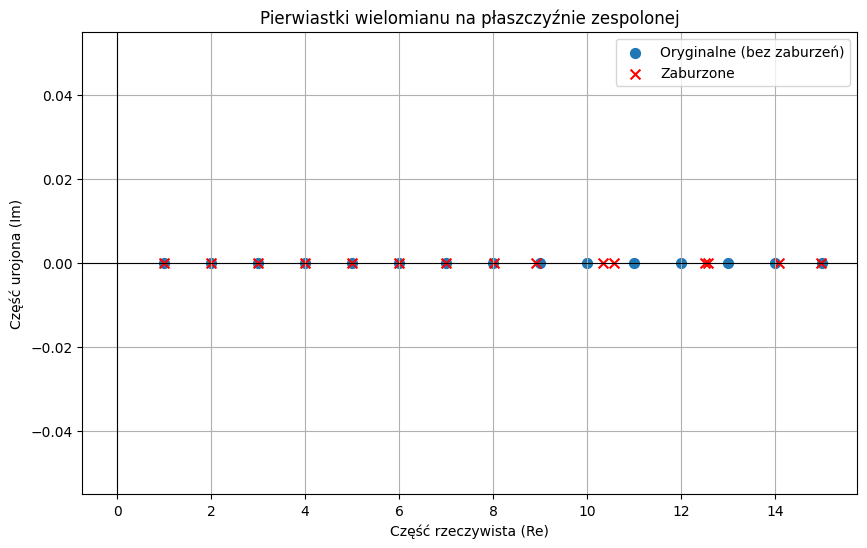

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

w1 = Polynomial([2, 3, 1])
pierwiastki_w1 = w1.roots()
print("Pierwiastki W(x):", pierwiastki_w1)
print()

dokladne_pierwiastki = np.arange(1, 16)
w2 = Polynomial.fromroots(dokladne_pierwiastki)

obliczone_pierwiastki = w2.roots()
print("Obliczone pierwiastki Wilkinsona:")
print(obliczone_pierwiastki)
print()

wspolczynniki_zaburzone = w2.coef.copy()
wspolczynniki_zaburzone[12] += 1e-5
w3 = Polynomial(wspolczynniki_zaburzone)

pierwiastki_zaburzone = w3.roots()

plt.figure(figsize=(10, 6))
plt.scatter(obliczone_pierwiastki.real, obliczone_pierwiastki.imag, label='Oryginalne (bez zaburzeń)', marker='o', s=50)
plt.scatter(pierwiastki_zaburzone.real, pierwiastki_zaburzone.imag, label='Zaburzone', marker='x', color='red', s=50)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Część rzeczywista (Re)')
plt.ylabel('Część urojona (Im)')
plt.title('Pierwiastki wielomianu na płaszczyźnie zespolonej')
plt.legend()
plt.grid(True)
plt.show()

***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

In [2]:
import math

I_f = [0.0] * 21
I_f[1] = 1.0 / math.e

for n in range(2, 21):
    I_f[n] = 1.0 - n * I_f[n-1]

I_b = [0.0] * 21
I_b[20] = 0.0

for n in range(20, 1, -1):
    I_b[n-1] = (1.0 - I_b[n]) / n

print(f"{'n':<3} | {'Kierunek w przód (Forward)':<25} | {'Kierunek wstecz (Backward)':<25}")
print("-" * 65)
for i in range(1, 21):
    print(f"{i:<3} | {I_f[i]:<25.10e} | {I_b[i]:<25.10e}")

dokladne_I1 = 1.0 / math.e
blad_I1 = abs(dokladne_I1 - I_b[1])

print(f"\nBłąd dla I_1 (backward): {blad_I1:.15e}")

n   | Kierunek w przód (Forward) | Kierunek wstecz (Backward)
-----------------------------------------------------------------
1   | 3.6787944117e-01          | 3.6787944117e-01         
2   | 2.6424111766e-01          | 2.6424111766e-01         
3   | 2.0727664703e-01          | 2.0727664703e-01         
4   | 1.7089341189e-01          | 1.7089341189e-01         
5   | 1.4553294057e-01          | 1.4553294057e-01         
6   | 1.2680235656e-01          | 1.2680235656e-01         
7   | 1.1238350407e-01          | 1.1238350407e-01         
8   | 1.0093196745e-01          | 1.0093196745e-01         
9   | 9.1612292994e-02          | 9.1612292990e-02         
10  | 8.3877070058e-02          | 8.3877070103e-02         
11  | 7.7352229359e-02          | 7.7352228863e-02         
12  | 7.1773247695e-02          | 7.1773253639e-02         
13  | 6.6947779970e-02          | 6.6947702692e-02         
14  | 6.2731080424e-02          | 6.2732162309e-02         
15  | 5.9033793642e-02          

# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

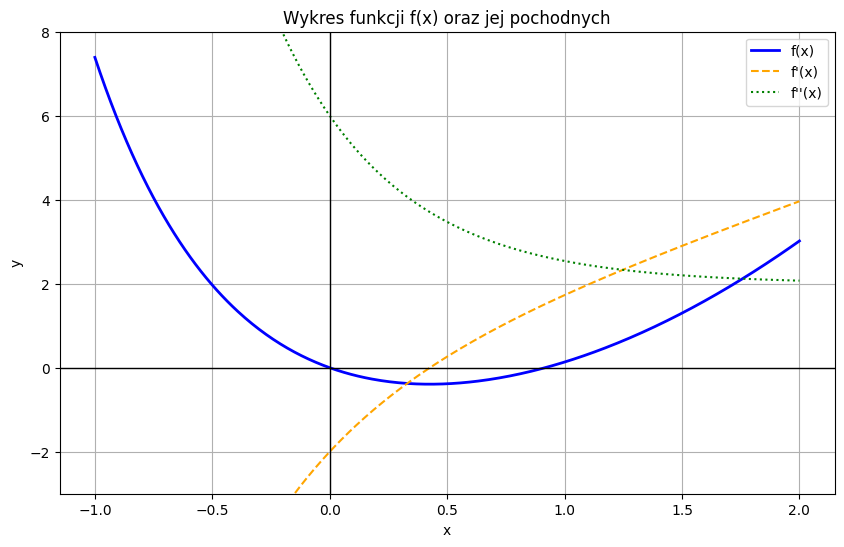

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.exp(-2*x) + x**2 - 1

def df(x):
    return -2 * np.exp(-2*x) + 2*x

def ddf(x):
    return 4 * np.exp(-2*x) + 2

x = np.linspace(-1, 2, 400)

plt.figure(figsize=(10, 6))
plt.plot(x, f(x), label='f(x)', color='blue', linewidth=2)
plt.plot(x, df(x), label="f'(x)", color='orange', linestyle='--')
plt.plot(x, ddf(x), label="f''(x)", color='green', linestyle=':')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.ylim(-3, 8)
plt.grid(True)
plt.legend()
plt.title('Wykres funkcji f(x) oraz jej pochodnych')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

In [5]:
def bisekcja(f, a, b, tol, max_iter):
    if f(a) * f(b) >= 0:
        return None, 0
        
    for i in range(max_iter):
        c = (a + b) / 2
        if abs(f(c)) < tol or abs(b - a) / 2 < tol:
            return c, i + 1
        
        if f(c) * f(a) < 0:
            b = c
        else:
            a = c
            
    return c, max_iter

def newton_raphson(f, df, x0, tol, max_iter):
    x = x0
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < tol:
            return x, i
            
        dfx = df(x)
        if dfx == 0:
            return None, i
            
        x_new = x - fx / dfx
        if abs(x_new - x) < tol:
            return x_new, i + 1
            
        x = x_new
        
    return x, max_iter

def sieczne(f, x0, x1, tol, max_iter):
    for i in range(max_iter):
        fx0 = f(x0)
        fx1 = f(x1)
        
        if abs(fx1) < tol:
            return x1, i
            
        if fx1 - fx0 == 0:
            return None, i
            
        x2 = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        
        if abs(x2 - x1) < tol:
            return x2, i + 1
            
        x0, x1 = x1, x2
        
    return x1, max_iter

***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


In [7]:
import numpy as np

tol = 1e-6
max_iter = 100

print("Pierwiastek 1 (w okolicach x = 0)")
root_b1, iter_b1 = bisekcja(f, -0.5, 0.5, tol, max_iter)
root_n1, iter_n1 = newton_raphson(f, df, -0.5, tol, max_iter)
root_s1, iter_s1 = sieczne(f, -0.5, 0.5, tol, max_iter)

print(f"Bisekcja: x = {root_b1:.8f}, iteracje = {iter_b1}")
print(f"Newton:   x = {root_n1:.8f}, iteracje = {iter_n1}")
print(f"Sieczne:  x = {root_s1:.8f}, iteracje = {iter_s1}\n")

print("Pierwiastek 2 (w okolicach x = 0.9)")
root_b2, iter_b2 = bisekcja(f, 0.5, 1.5, tol, max_iter)
root_n2, iter_n2 = newton_raphson(f, df, 1.5, tol, max_iter)
root_s2, iter_s2 = sieczne(f, 0.5, 1.5, tol, max_iter)

print(f"Bisekcja: x = {root_b2:.8f}, iteracje = {iter_b2}")
print(f"Newton:   x = {root_n2:.8f}, iteracje = {iter_n2}")
print(f"Sieczne:  x = {root_s2:.8f}, iteracje = {iter_s2}")

Pierwiastek 1 (w okolicach x = 0)
Bisekcja: x = 0.00000000, iteracje = 1
Newton:   x = -0.00000000, iteracje = 5
Sieczne:  x = 0.33742334, iteracje = 4

Pierwiastek 2 (w okolicach x = 0.9)
Bisekcja: x = 0.91656303, iteracje = 19
Newton:   x = 0.91656260, iteracje = 4
Sieczne:  x = 0.91656260, iteracje = 6


***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

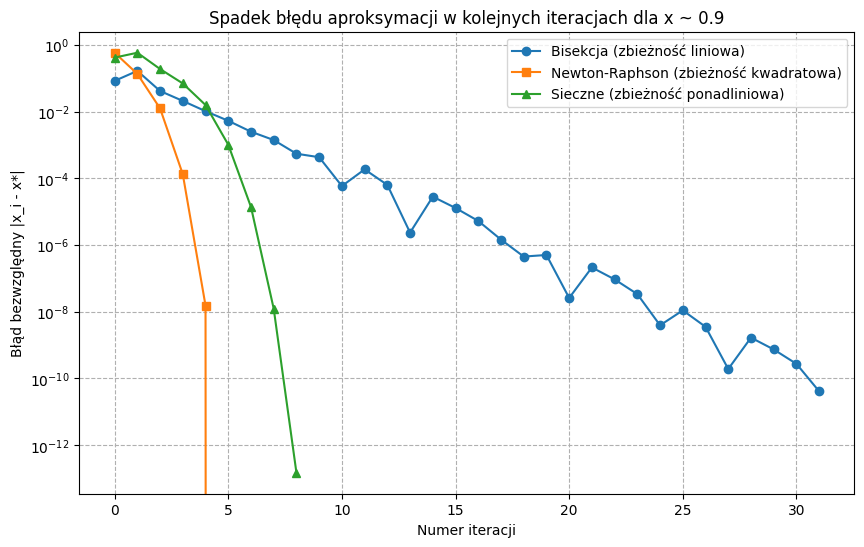

In [8]:
import matplotlib.pyplot as plt

def bisekcja_hist(f, a, b, tol, max_iter):
    hist = []
    for i in range(max_iter):
        c = (a + b) / 2
        hist.append(c)
        if abs(f(c)) < tol or abs(b - a) / 2 < tol:
            break
        if f(c) * f(a) < 0: b = c
        else: a = c
    return hist

def newton_hist(f, df, x0, tol, max_iter):
    x = x0
    hist = [x]
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < tol: break
        dfx = df(x)
        if dfx == 0: break
        x_new = x - fx / dfx
        hist.append(x_new)
        if abs(x_new - x) < tol: break
        x = x_new
    return hist

def sieczne_hist(f, x0, x1, tol, max_iter):
    hist = [x0, x1]
    for i in range(max_iter):
        fx0 = f(x0)
        fx1 = f(x1)
        if abs(fx1) < tol: break
        if fx1 - fx0 == 0: break
        x2 = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        hist.append(x2)
        if abs(x2 - x1) < tol: break
        x0, x1 = x1, x2
    return hist

hist_b = bisekcja_hist(f, 0.5, 1.5, 1e-10, 100)
hist_n = newton_hist(f, df, 1.5, 1e-10, 100)
hist_s = sieczne_hist(f, 0.5, 1.5, 1e-10, 100)

x_dokladne = hist_n[-1]

err_b = [abs(x - x_dokladne) for x in hist_b]
err_n = [abs(x - x_dokladne) for x in hist_n]
err_s = [abs(x - x_dokladne) for x in hist_s]

plt.figure(figsize=(10, 6))
plt.semilogy(err_b, marker='o', label='Bisekcja (zbieżność liniowa)')
plt.semilogy(err_n, marker='s', label='Newton-Raphson (zbieżność kwadratowa)')
plt.semilogy(err_s, marker='^', label='Sieczne (zbieżność ponadliniowa)')

plt.title('Spadek błędu aproksymacji w kolejnych iteracjach dla x ~ 0.9')
plt.xlabel('Numer iteracji')
plt.ylabel('Błąd bezwzględny |x_i - x*|')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()